# Mask2Former (official) — fine-tune on DIVA-HisDB CS18

Assumes the prepared `Mask2Former/` folder (patched + weights + config + `train_cs18.py`) and the `DIVA-HisDB/` data folder are both already on your Google Drive.

**Runtime:** GPU (T4/L4/A100). `Runtime → Change runtime type → GPU`.

## 1  Mount Drive + mirror to local SSD (Drive FUSE is slow)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# ── adjust these to your Drive layout ─────────────────────────────────────────
M2F_DRIVE   = '/content/drive/MyDrive/Thesis/Mask2Former'
CS18_DRIVE  = '/content/drive/MyDrive/Thesis/00_data/DIVA-HisDB'
OUTPUT_DRIVE= '/content/drive/MyDrive/Thesis/mask2former_cs18_output'

In [ ]:
import shutil
from pathlib import Path

M2F_LOCAL  = Path('/content/Mask2Former')
CS18_LOCAL = Path('/content/DIVA-HisDB')

if not M2F_LOCAL.exists():
    print('copying Mask2Former → /content …')
    shutil.copytree(M2F_DRIVE, M2F_LOCAL)
if not CS18_LOCAL.exists():
    print('copying DIVA-HisDB → /content …')
    shutil.copytree(CS18_DRIVE, CS18_LOCAL)
print('ready:', M2F_LOCAL, CS18_LOCAL)

copying Mask2Former → /content …
copying DIVA-HisDB → /content …
ready: /content/Mask2Former /content/DIVA-HisDB


## 2  Install deps + recompile MSDeformAttn for Colab's GPU

The `.so` you uploaded was built for your laptop GPU. It must be rebuilt for the Colab GPU (T4=7.5, L4=8.9, A100=8.0).

In [ ]:
!pip install -q cython scipy shapely timm h5py submitit scikit-image opencv-python
!pip install -q 'git+https://github.com/facebookresearch/detectron2.git'

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 76.0/76.0 kB 7.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.2/50.2 kB 4.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.9/91.9 kB 9.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.5/154.5 kB 17.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 97.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.3/57.3 kB 7.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 269.8/269.8 kB 29.8 MB/s eta 0:00:00


In [ ]:
import os, subprocess, sys, shutil
ops_dir = M2F_LOCAL / 'mask2former/modeling/pixel_decoder/ops'
shutil.rmtree(ops_dir / 'build', ignore_errors=True)
os.environ['TORCH_CUDA_ARCH_LIST'] = '7.0;7.5;8.0;8.6;8.9'
subprocess.run(
    [sys.executable, '-m', 'pip', 'install', '--no-build-isolation', '.'],
    cwd=ops_dir, check=True,
)

CompletedProcess(args=['/usr/bin/python3', '-m', 'pip', 'install', '--no-build-isolation', '.'], returncode=0)

In [ ]:
import torch, MultiScaleDeformableAttention, detectron2  # noqa: F401
print('torch       :', torch.__version__, '| cuda', torch.version.cuda)
print('detectron2  :', detectron2.__version__)
print('GPU         :', torch.cuda.get_device_name(0))
print('MSDeformAttn: OK')

torch       : 2.10.0+cu128 | cuda 12.8
detectron2  : 0.6
GPU         : NVIDIA L4
MSDeformAttn: OK


## 3  Train

`CS18_ROOT` env var tells `train_cs18.py` where to find the data; `OUTPUT_DIR` overrides the config so checkpoints land where you want.

In [ ]:
# %load_ext tensorboard
# %tensorboard --logdir /content/output/cs18_R50

In [ ]:
import os
os.environ['CS18_ROOT'] = str(CS18_LOCAL)
os.chdir(M2F_LOCAL)
!python train_cs18.py \
    --config-file configs/cs18/maskformer2_R50_cs18.yaml \
    --num-gpus 1 \
    OUTPUT_DIR /content/output/cs18_R50

Streaming output truncated to the last 5000 lines.
      (conv1): Conv2d(
        3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False
        (norm): FrozenBatchNorm2d(num_features=64, eps=1e-05)
      )
    )
    (res2): Sequential(
      (0): BottleneckBlock(
        (shortcut): Conv2d(
          64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False
          (norm): FrozenBatchNorm2d(num_features=256, eps=1e-05)
        )
        (conv1): Conv2d(
          64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False
          (norm): FrozenBatchNorm2d(num_features=64, eps=1e-05)
        )
        (conv2): Conv2d(
          64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False
          (norm): FrozenBatchNorm2d(num_features=64, eps=1e-05)
        )
        (conv3): Conv2d(
          64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False
          (norm): FrozenBatchNorm2d(num_features=256, eps=1e-05)
        )
      )
      (1): BottleneckBlock(
        (c

## 4  Sync trained model back to Drive

In [ ]:
import shutil
from pathlib import Path
out_drive = Path(OUTPUT_DRIVE)
out_drive.parent.mkdir(parents=True, exist_ok=True)
if out_drive.exists():
    shutil.rmtree(out_drive)
shutil.copytree('/content/output/cs18_R50', out_drive)
print('synced →', out_drive)

synced → /content/drive/MyDrive/Thesis/mask2former_cs18_output


In [ ]:
import shutil
from google.colab import files

# Define the base name for the zip archive and the folder to compress
zip_base_path = '/content/cs18_R50_output'
folder_to_zip = '/content/output/cs18_R50'

# Create the zip archive
shutil.make_archive(zip_base_path, 'zip', folder_to_zip)
zip_file = f"{zip_base_path}.zip"
print(f"Created archive: {zip_file}")

# Trigger the download
files.download(zip_file)


Created archive: /content/cs18_R50_output.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 5 Inference

e-codices_csg-0018_159_max.jpg: 87 text-lines (scores min=0.814 max=0.975)
saved → /content/output/cs18_R50/pred_e-codices_csg-0018_159_max.jpg
saved → /content/drive/MyDrive/Thesis/mask2former_cs18_output/pred_e-codices_csg-0018_159_max.jpg


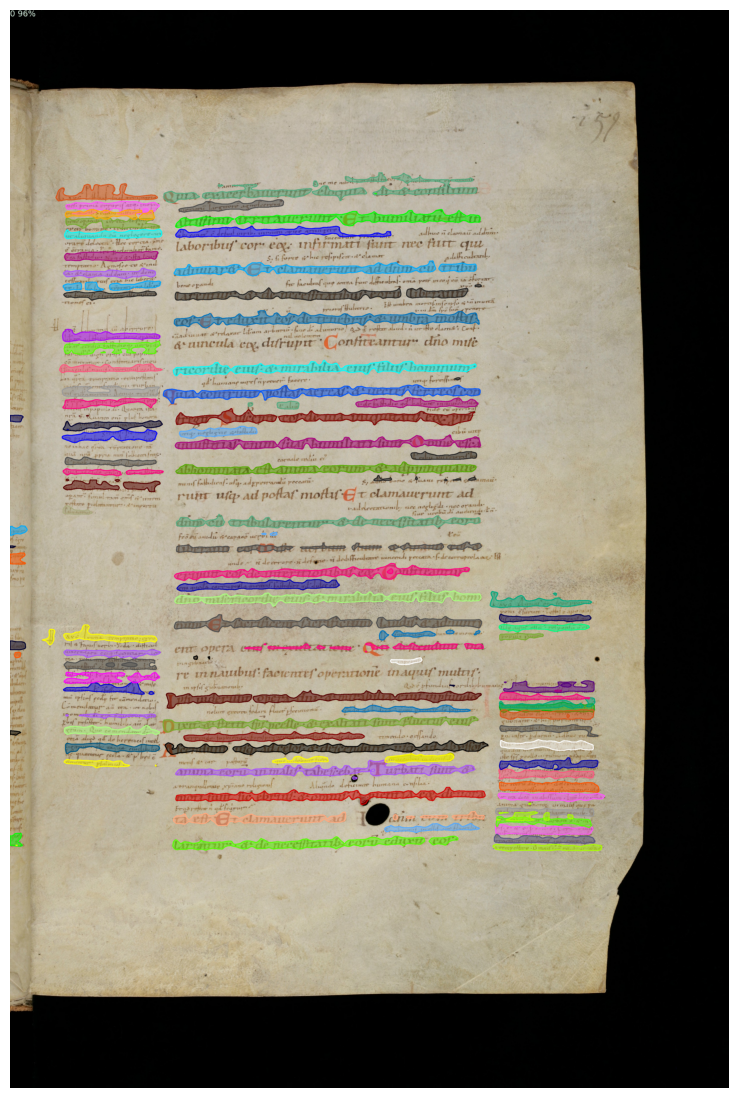

In [ ]:
import json, random, sys, cv2, os
from pathlib import Path
import matplotlib.pyplot as plt

os.environ['CS18_ROOT'] = str(CS18_LOCAL)

sys.path.insert(0, str(M2F_LOCAL))
if 'train_cs18' in sys.modules:
    del sys.modules['train_cs18']

from detectron2.config import get_cfg
from detectron2.engine import DefaultPredictor
from detectron2.data import MetadataCatalog, DatasetCatalog
from detectron2.projects.deeplab import add_deeplab_config
from detectron2.utils.visualizer import Visualizer, ColorMode
from mask2former import add_maskformer2_config
from train_cs18 import register_cs18

DatasetCatalog.clear()
MetadataCatalog.clear()

SCORE_THRESH = 0.5
register_cs18()
metadata = MetadataCatalog.get('cs18_test')

cfg = get_cfg()
add_deeplab_config(cfg); add_maskformer2_config(cfg)
cfg.merge_from_file(str(M2F_LOCAL / 'configs/cs18/maskformer2_R50_cs18.yaml'))
cfg.MODEL.WEIGHTS = '/content/output/cs18_R50/model_final.pth'
cfg.MODEL.MASK_FORMER.TEST.OBJECT_MASK_THRESHOLD = SCORE_THRESH
cfg.freeze()
predictor = DefaultPredictor(cfg)

test_json = json.load(open(CS18_LOCAL / 'coco_dataset_CS18' / 'test.json'))
img_dir   = CS18_LOCAL / 'CS18' / 'img-CS18' / 'img' / 'public-test'
fname     = random.choice(test_json['images'])['file_name']
img_path  = img_dir / fname
img       = cv2.imread(str(img_path))

inst = predictor(img)['instances'].to('cpu')
inst = inst[inst.scores >= SCORE_THRESH]
print(f'{fname}: {len(inst)} text-lines (scores '
      f'min={float(inst.scores.min()):.3f} max={float(inst.scores.max()):.3f})')

viz = Visualizer(img[:, :, ::-1], metadata=metadata, scale=0.5,
                 instance_mode=ColorMode.IMAGE)
result = viz.draw_instance_predictions(inst).get_image()

out_local = Path('/content/output/cs18_R50') / f'pred_{img_path.stem}.jpg'
cv2.imwrite(str(out_local), result[:, :, ::-1])
out_drive = Path(OUTPUT_DRIVE) / out_local.name
out_drive.parent.mkdir(parents=True, exist_ok=True)
cv2.imwrite(str(out_drive), result[:, :, ::-1])
print(f'saved → {out_local}\nsaved → {out_drive}')

plt.figure(figsize=(10, 14))
plt.imshow(result); plt.axis('off'); plt.show()
